# This Python script is used for drug grouping and structural analysis.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [18]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\files"
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\figures"

In [19]:

import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. Load the drug CSV file
# ============================================
df = pd.read_csv(f'{file_path}\drugs.csv') 
df = df.fillna("Other")  # Replace missing entries with "Unknown"


In [20]:
df.columns

Index(['Plate Color', 'Plate Number', 'Well', 'Aliqout Type', 'ProductName',
       'Synonyms', 'CAS Number', 'M.Wt', 'Target', 'PathWay',
       'Biological Activity', 'Saltdata', 'Formula', 'Solubility', 'Solvent',
       'Batch No.', 'Quantity', 'Smiles', 'URL', 'Research Area',
       'Clinical Information', 'BaseName', 'Priority', 'SearchText',
       'Category'],
      dtype='object')

In [10]:


# ============================================
# 2. Preprocessing: keep only the first entry if separated by ";"
# ============================================
def first_item(x):
    """Return only the first item if multiple values are separated by ';'."""
    if not isinstance(x, str):
        return "Unknown"
    return x.split(";")[0].strip()

df["PathWay_clean"]      = df["PathWay"].apply(first_item)
df["Target_clean"]       = df["Target"].apply(first_item)
df["ResearchArea_clean"] = df["Research Area"].apply(first_item)


# ============================================
# 3. Count top categories (Top 15)
# ============================================
path_counts   = df["PathWay_clean"].value_counts().head(10)
target_counts = df["Target_clean"].value_counts().head(9)
area_counts   = df["ResearchArea_clean"].value_counts().head(7)

print("=== Top 20 Pathways ===")
print(path_counts)
print("\n=== Top 20 Targets ===")
print(target_counts)
print("\n=== Top 20 Research Areas ===")
print(area_counts)



=== Top 20 Pathways ===
PathWay_clean
GPCR/G Protein                      36
Anti-infection                      35
Membrane Transporter/Ion Channel    21
Immunology/Inflammation             16
Metabolic Enzyme/Protease           15
Autophagy                           14
JAK/STAT Signaling                   9
Protein Tyrosine Kinase/RTK          6
Apoptosis                            4
Cell Cycle/DNA Damage                4
Name: count, dtype: int64

=== Top 20 Targets ===
Target_clean
Autophagy                  26
Histamine Receptor         17
Endogenous Metabolite      15
Glucocorticoid Receptor    12
Dopamine Receptor           9
EGFR                        9
iGluR                       8
Cytochrome P450             6
nAChR                       6
Name: count, dtype: int64

=== Top 20 Research Areas ===
ResearchArea_clean
Cancer                     53
Neurological Disease       38
Inflammation/Immunology    32
Infection                  18
Metabolic Disease          14
Endocrinology

In [15]:
map_dict = dict(zip(df["ProductName"], df["PathWay_clean"]))
map_dict

{'Dexpramipexole (dihydrochloride)': 'GPCR/G Protein',
 'Betahistine': 'GPCR/G Protein',
 'Benztropine (mesylate)': 'GPCR/G Protein',
 'Emedastine': 'GPCR/G Protein',
 'Mebhydrolin': 'GPCR/G Protein',
 'Azatadine (dimaleate)': 'GPCR/G Protein',
 'Dimenhydrinate': 'GPCR/G Protein',
 'Almotriptan (malate)': 'GPCR/G Protein',
 'Betamethasone valerate': 'Immunology/Inflammation',
 'Varenicline (Hydrochloride)': 'Membrane Transporter/Ion Channel',
 'Pipecuronium (bromide)': 'Membrane Transporter/Ion Channel',
 'Rocuronium (Bromide)': 'Membrane Transporter/Ion Channel',
 'Fluphenazine decanoate': 'GPCR/G Protein',
 'Carbenoxolone (disodium)': 'Anti-infection',
 'Nordihydroguaiaretic acid': 'Apoptosis',
 'Pamapimod': 'Autophagy',
 'Amiodarone (hydrochloride)': 'Autophagy',
 'Î³-Oryzanol': 'Epigenetics',
 'Linaclotide': 'GPCR/G Protein',
 'Antazoline (hydrochloride)': 'GPCR/G Protein',
 'Epinastine (hydrochloride)': 'GPCR/G Protein',
 'Alcaftadine': 'GPCR/G Protein',
 'Prucalopride': 'GPCR/G P

In [16]:
from collections import defaultdict

target_to_drugs2 = defaultdict(list)

for drug, target in map_dict.items():
    target_to_drugs2[target].append(drug)

print(dict(target_to_drugs2))

{'GPCR/G Protein': ['Dexpramipexole (dihydrochloride)', 'Betahistine', 'Benztropine (mesylate)', 'Emedastine', 'Mebhydrolin', 'Azatadine (dimaleate)', 'Dimenhydrinate', 'Almotriptan (malate)', 'Fluphenazine decanoate', 'Linaclotide', 'Antazoline (hydrochloride)', 'Epinastine (hydrochloride)', 'Alcaftadine', 'Prucalopride', 'Chloropyramine hydrochloride', 'Oxybutynin (chloride)', 'Pindolol', 'Tripelennamine (hydrochloride)', 'Desloratadine', 'Cetirizine (dihydrochloride)', 'Bepotastine', 'Chlorpheniramine (maleate)', 'Levocetirizine (dihydrochloride)', 'Procyclidine (hydrochloride)', 'Pranlukast (hemihydrate)', 'Acetophenazine (dimaleate)', 'Alizapride (hydrochloride)', 'Fexofenadine (hydrochloride)', 'Amisulpride', 'Betazole', 'Anamorelin', 'Mecamylamine (hydrochloride)', 'Diphenylpyraline (hydrochloride)', 'Monomethyl fumarate', 'Haloperidol', 'Pergolide (mesylate)'], 'Immunology/Inflammation': ['Betamethasone valerate', 'Clobetasone butyrate', 'Betamethasone dipropionate', 'Simvastat

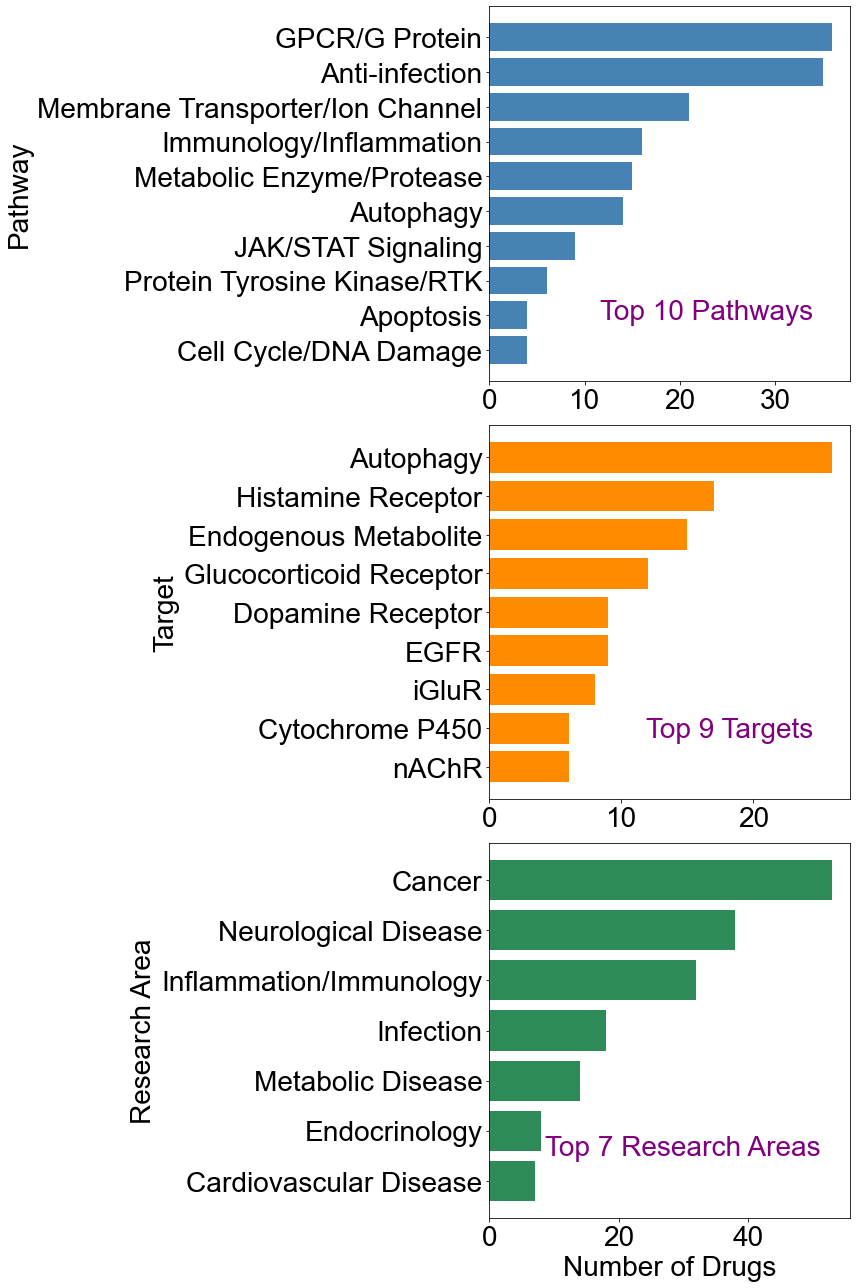

In [11]:

# ============================================
# 4. Plot 3 stacked horizontal bar charts
# ============================================

# Plot style settings
# plt.rcParams['font.size'] = 16
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 600
plt.rcParams["font.family"] = "Arial" 
# Create a vertical layout with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))  # 3 rows, 1 column

numer = 28
numer2 = 28
# ---------- (1) PathWay horizontal bar plot ----------
axes[0].barh(path_counts.index, path_counts.values, color="steelblue")
# axes[0].set_title("Top 15 Pathways", fontsize=14)
# axes[0].set_xlabel("Number of Compounds")
axes[0].set_ylabel("Pathway",fontsize = numer)
axes[0].invert_yaxis()  # Show the most frequent at the top
# Add title inside subplot (bottom-right corner)
axes[0].text(
    0.90, 0.15,
    "Top 10 Pathways",
    transform=axes[0].transAxes,
    fontsize=numer2,
    fontweight='normal',       # <-- bold
    color='purple',          # <-- purple text
    ha='right', va='bottom'
)

# ---------- (2) Target horizontal bar plot ----------
axes[1].barh(target_counts.index, target_counts.values, color="darkorange")
# axes[1].set_title("Top 15 Targets", fontsize=14)
# axes[1].set_xlabel("Number of Compounds")
axes[1].set_ylabel("Target",fontsize = numer)
axes[1].invert_yaxis()
axes[1].text(
    0.90, 0.15,
    "Top 9 Targets",
    transform=axes[1].transAxes,
    fontsize=numer2,
    fontweight='normal',       # <-- bold
    color='purple',          # <-- purple text
    ha='right', va='bottom'
)

# ---------- (3) Research Area horizontal bar plot ----------
axes[2].barh(area_counts.index, area_counts.values, color="seagreen")
# axes[2].set_title("Top 15 Research Areas", fontsize=14)
axes[2].set_xlabel("Number of Drugs",fontsize = numer)
axes[2].set_ylabel("Research Area",fontsize = numer)
axes[2].invert_yaxis()
axes[2].text(
    0.92, 0.15,
    "Top 7 Research Areas",
    transform=axes[2].transAxes,
    fontsize=numer2,
    fontweight='normal',       # <-- bold
    color='purple',          # <-- purple text
    ha='right', va='bottom'
)

for ax in axes:
    # 1) control tick label size
    ax.tick_params(axis='both', labelsize=numer)

    # 2) control tick label font family / weight
    for lab in ax.get_yticklabels():
        lab.set_fontfamily("Arial")
# Tight layout and save the figure
plt.tight_layout()
plt.savefig(f'{figure_path}\\barplot_drug_pathway_target_researcharea.svg', dpi=600)
plt.show()

# print(f"Stacked plot saved to:\n{save_path}")

# MOLECULE WEIGHT DISTRIBUTION

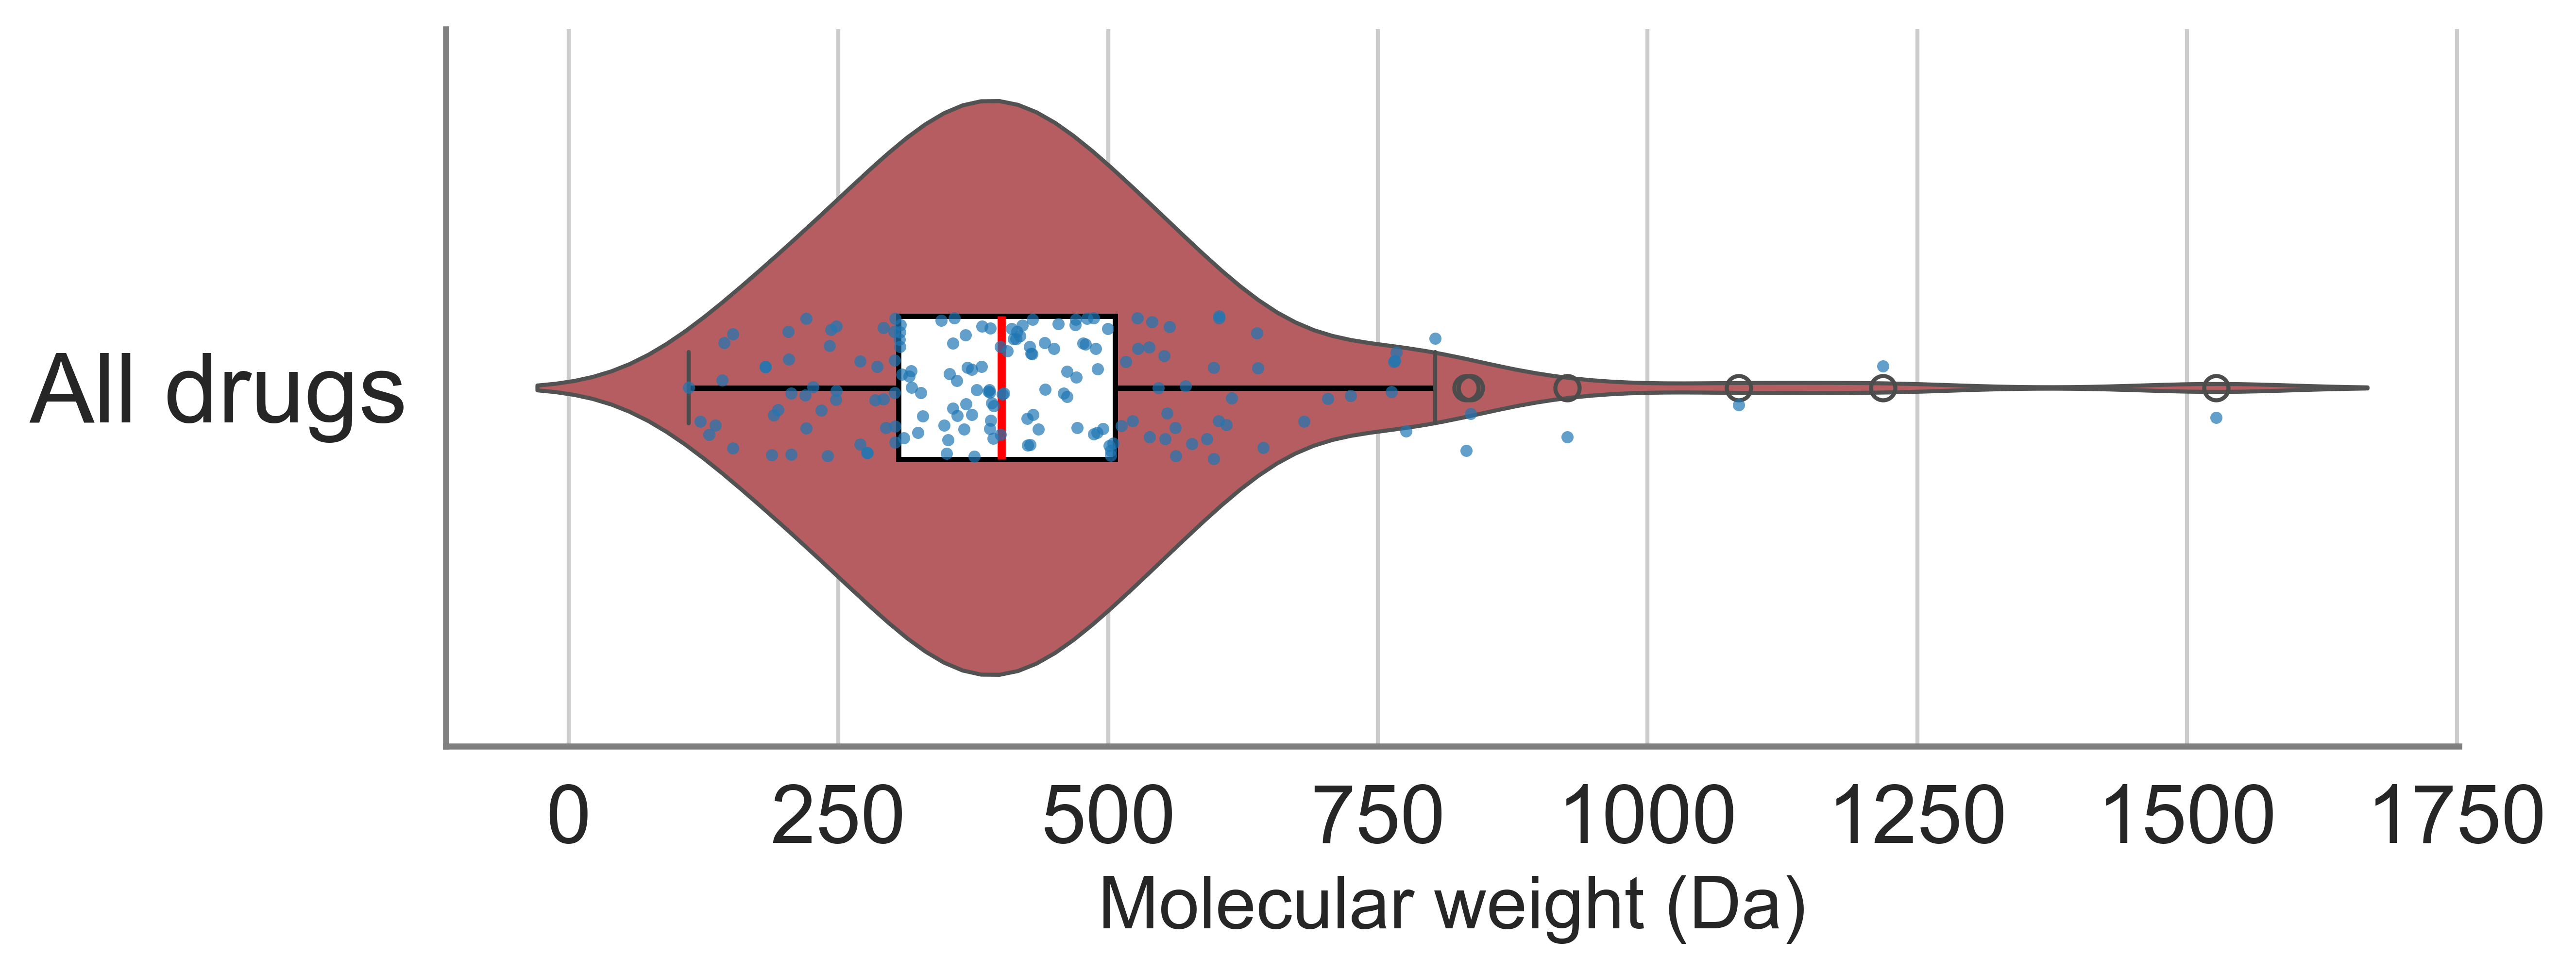

In [10]:
import seaborn as sns

df["M.Wt"] = pd.to_numeric(df["M.Wt"], errors="coerce")
mw = df["M.Wt"].dropna()

plot_df = pd.DataFrame({
    "MolecularWeight": mw,
    "Group": ["All drugs"] * len(mw)
})

# ================================
# 2. Plot
# ================================
sns.set(style="whitegrid")

plt.figure(figsize=(9, 3.5))

# --- Violin ---
sns.violinplot(
    x="MolecularWeight",
    y="Group",
    data=plot_df,
    inner=None,
    color="#c44e52",
    linewidth=1.0
)

# --- Boxplot ---
sns.boxplot(
    x="MolecularWeight",
    y="Group",
    data=plot_df,
    width=0.2,
    showcaps=True,
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 1.3},
    whiskerprops={"color": "black", "linewidth": 1.3},
    medianprops={"color": "red", "linewidth": 2}
)

# --- Scatter ---
sns.stripplot(
    x="MolecularWeight",
    y="Group",
    data=plot_df,
    color="tab:blue",
    alpha=0.7,
    size=3
)

# ================================
# 3. Axis styling (keep left spine)
# ================================
ax = plt.gca()

# Keep left Y-axis line, make it bold
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.5)
ax.spines['left'].set_color("gray")

# Make bottom X-axis line bold
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color("gray")

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: keep y tick (one category)
plt.yticks(fontsize=24)
plt.xticks(fontsize=20)
plt.xlabel("Molecular weight (Da)", fontsize=18)
plt.ylabel("")

plt.tight_layout()

# save
plt.savefig(f'{figure_path}\\barplot_drug_mw_distribution.svg', dpi=800)

plt.show()

# STRUCTURE SIMILARITY 

In [11]:
from rdkit import Chem
from rdkit.Chem import Crippen


[20:32:02] SMILES Parse Error: syntax error while parsing: CN(C1=CC(SC2=C/C(C=CC2=N3)=[N+](C)\C)=C3C=C1)C.[3
[20:32:02] SMILES Parse Error: Failed parsing SMILES 'CN(C1=CC(SC2=C/C(C=CC2=N3)=[N+](C)\C)=C3C=C1)C.[3' for input: 'CN(C1=CC(SC2=C/C(C=CC2=N3)=[N+](C)\C)=C3C=C1)C.[3'
[20:32:02] SMILES Parse Error: syntax error while parsing: N[C@H]1[C@H](C2=CC=CC=C2)C1.[0.5H2SO4]
[20:32:02] SMILES Parse Error: Failed parsing SMILES 'N[C@H]1[C@H](C2=CC=CC=C2)C1.[0.5H2SO4]' for input: 'N[C@H]1[C@H](C2=CC=CC=C2)C1.[0.5H2SO4]'
[20:32:02] SMILES Parse Error: syntax error while parsing: O=C(C1=CC=C(OCCCCC2=CC=CC=C2)C=C1)NC3=C4C(C(C=C(C5=NN=NN5)O4)=O)=CC=C3.[1/2].O
[20:32:02] SMILES Parse Error: Failed parsing SMILES 'O=C(C1=CC=C(OCCCCC2=CC=CC=C2)C=C1)NC3=C4C(C(C=C(C5=NN=NN5)O4)=O)=CC=C3.[1/2].O' for input: 'O=C(C1=CC=C(OCCCCC2=CC=CC=C2)C=C1)NC3=C4C(C(C=C(C5=NN=NN5)O4)=O)=CC=C3.[1/2].O'
[20:32:02] SMILES Parse Error: syntax error while parsing: FC1=CC=C(C2=C(C3=CC=CC=C3)C(C(NC4=CC=CC=C4)=O)=C(C(C)C)N

Valid molecules for plotting: 167


C:\Users\jiangy5\AppData\Local\Temp\ipykernel_18020\1898759794.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid[color_col] = df_valid[color_col].fillna("Others")


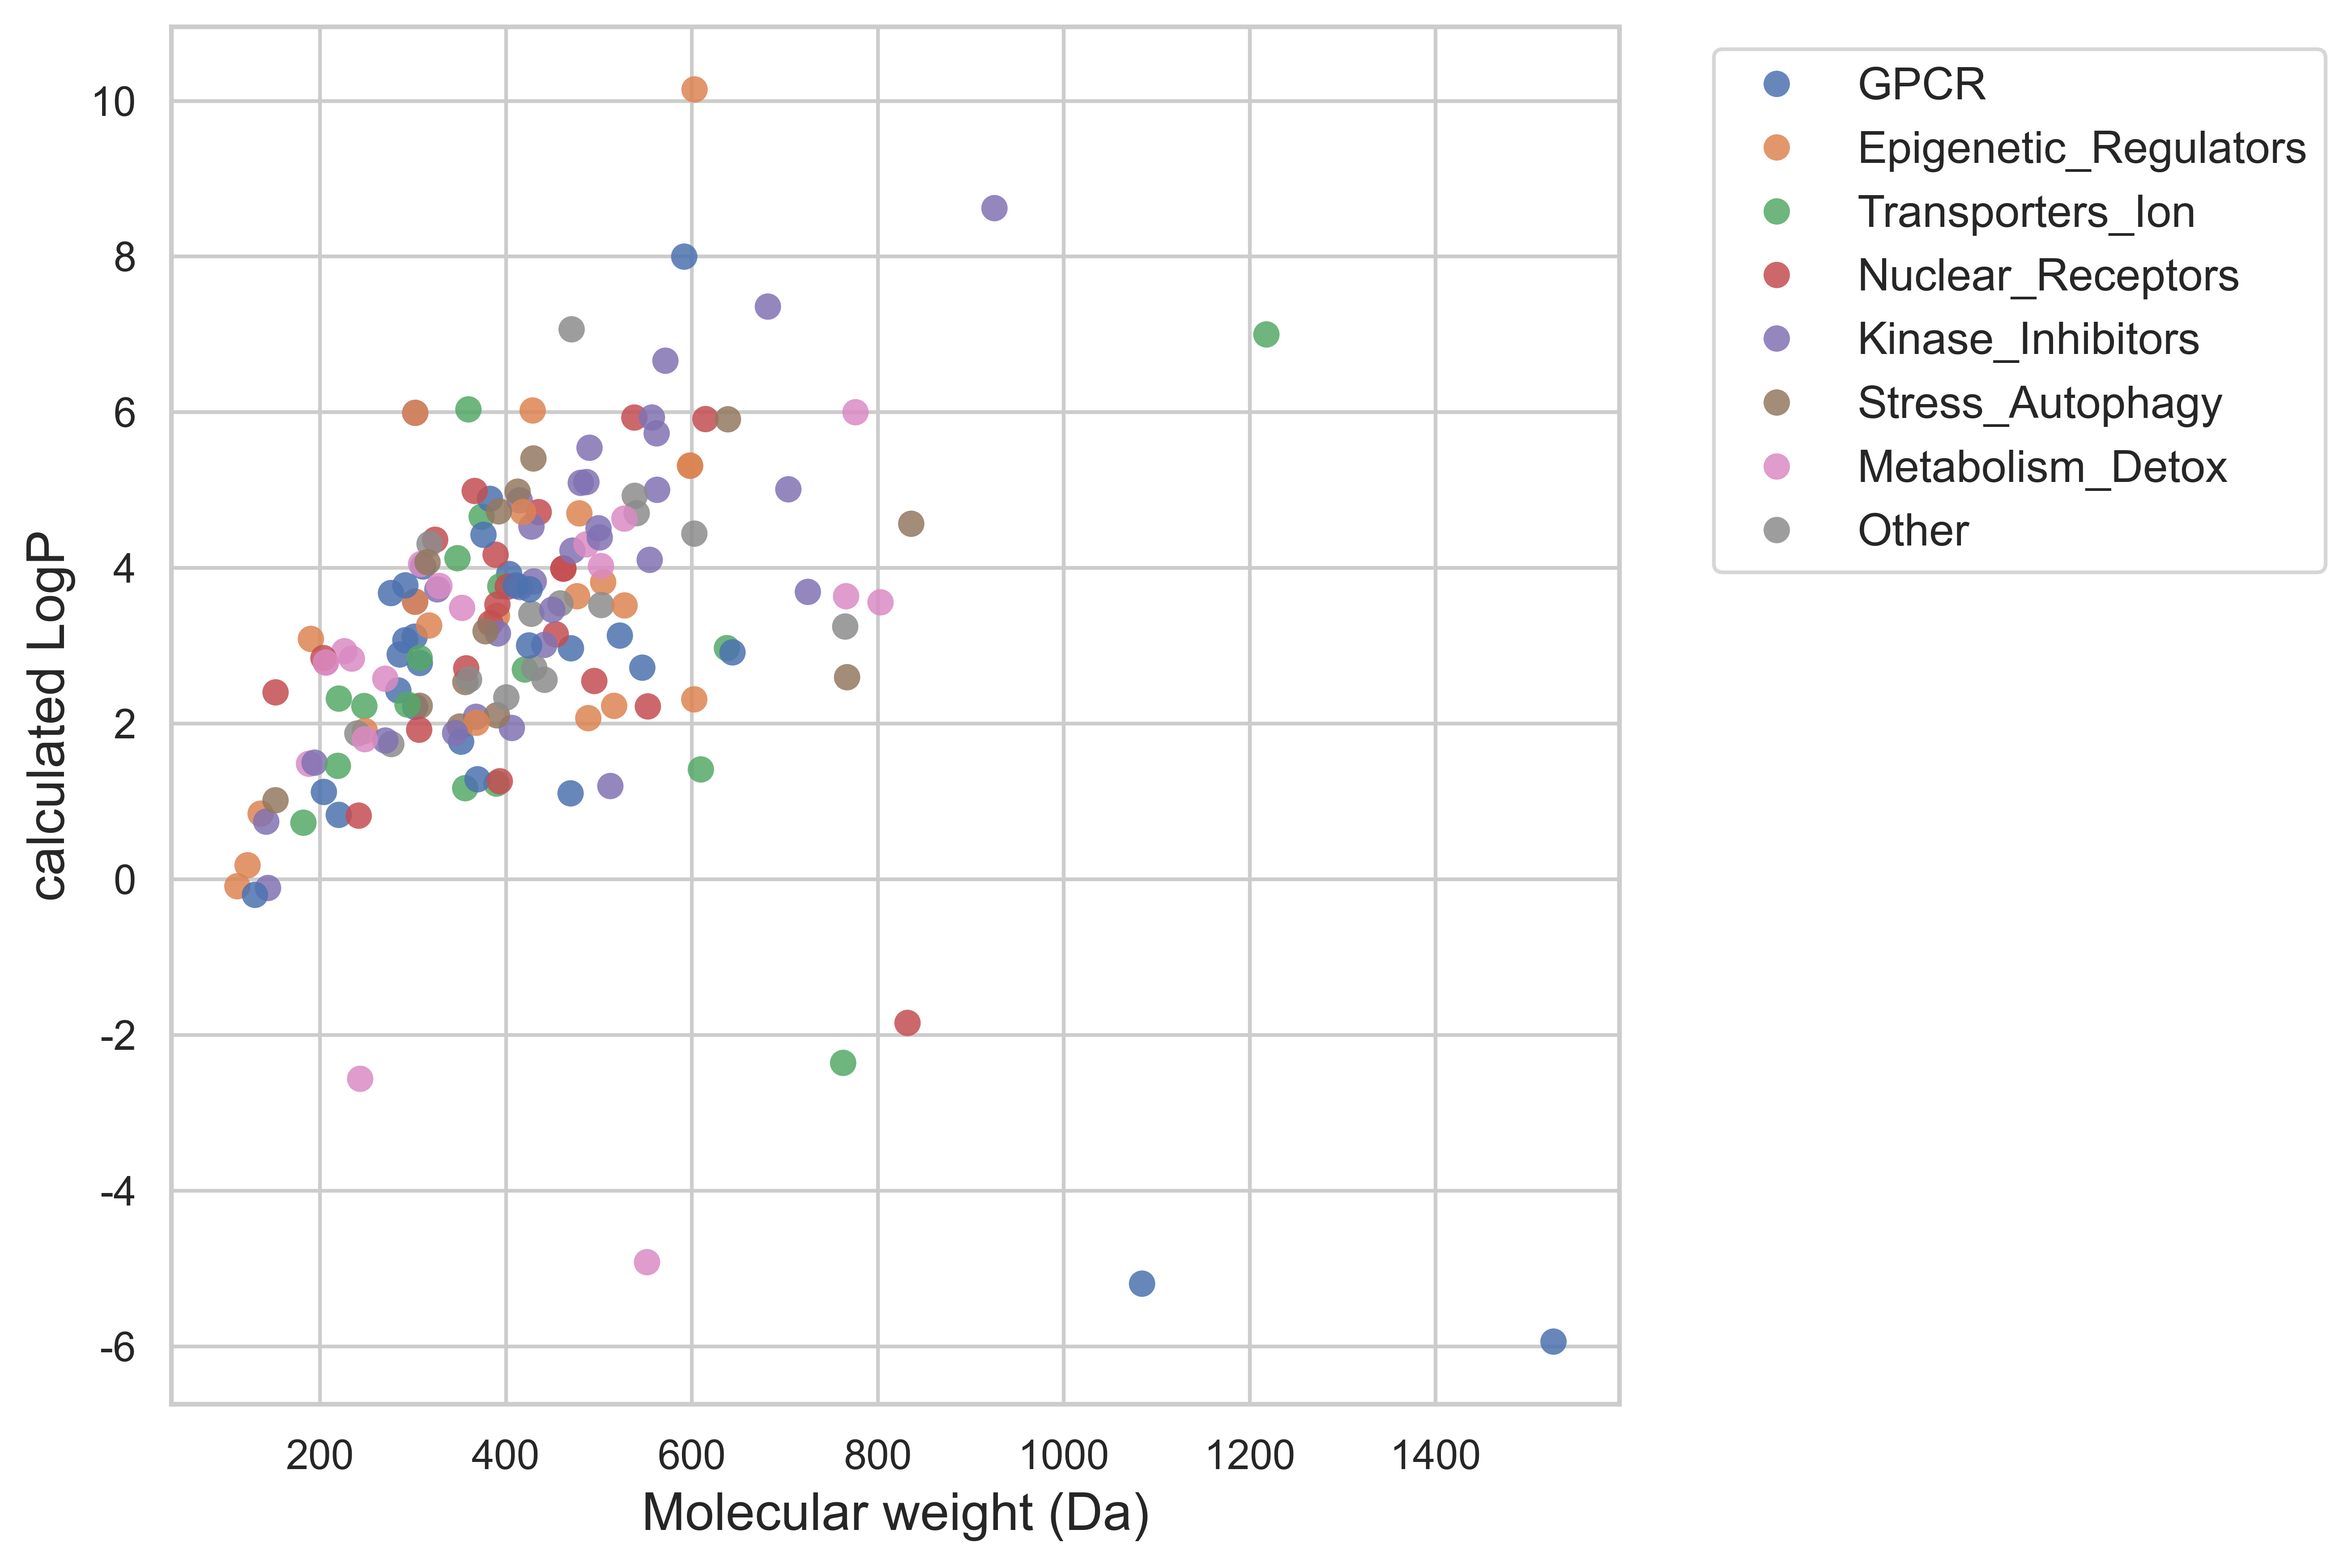

In [12]:



smiles_col = "Smiles"
mw_col = "M.Wt"       # your dataset already contains MW


# ==========================
# 2. Compute cLogP from SMILES
# ==========================
def compute_logp(smi):
    """Compute RDKit cLogP value from SMILES."""
    if not isinstance(smi, str):
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Crippen.MolLogP(mol)

df["cLogP"] = df[smiles_col].apply(compute_logp)

# Ensure MW is numeric
df[mw_col] = pd.to_numeric(df[mw_col], errors="coerce")

# Filter valid rows (both MW and cLogP must be present)
df_valid = df.dropna(subset=[mw_col, "cLogP"])
print("Valid molecules for plotting:", df_valid.shape[0])


# ==========================
# 3. Choose coloring category
# ==========================
color_col = "Category"      # or "PathWay", "Research Area", etc.
df_valid[color_col] = df_valid[color_col].fillna("Others")


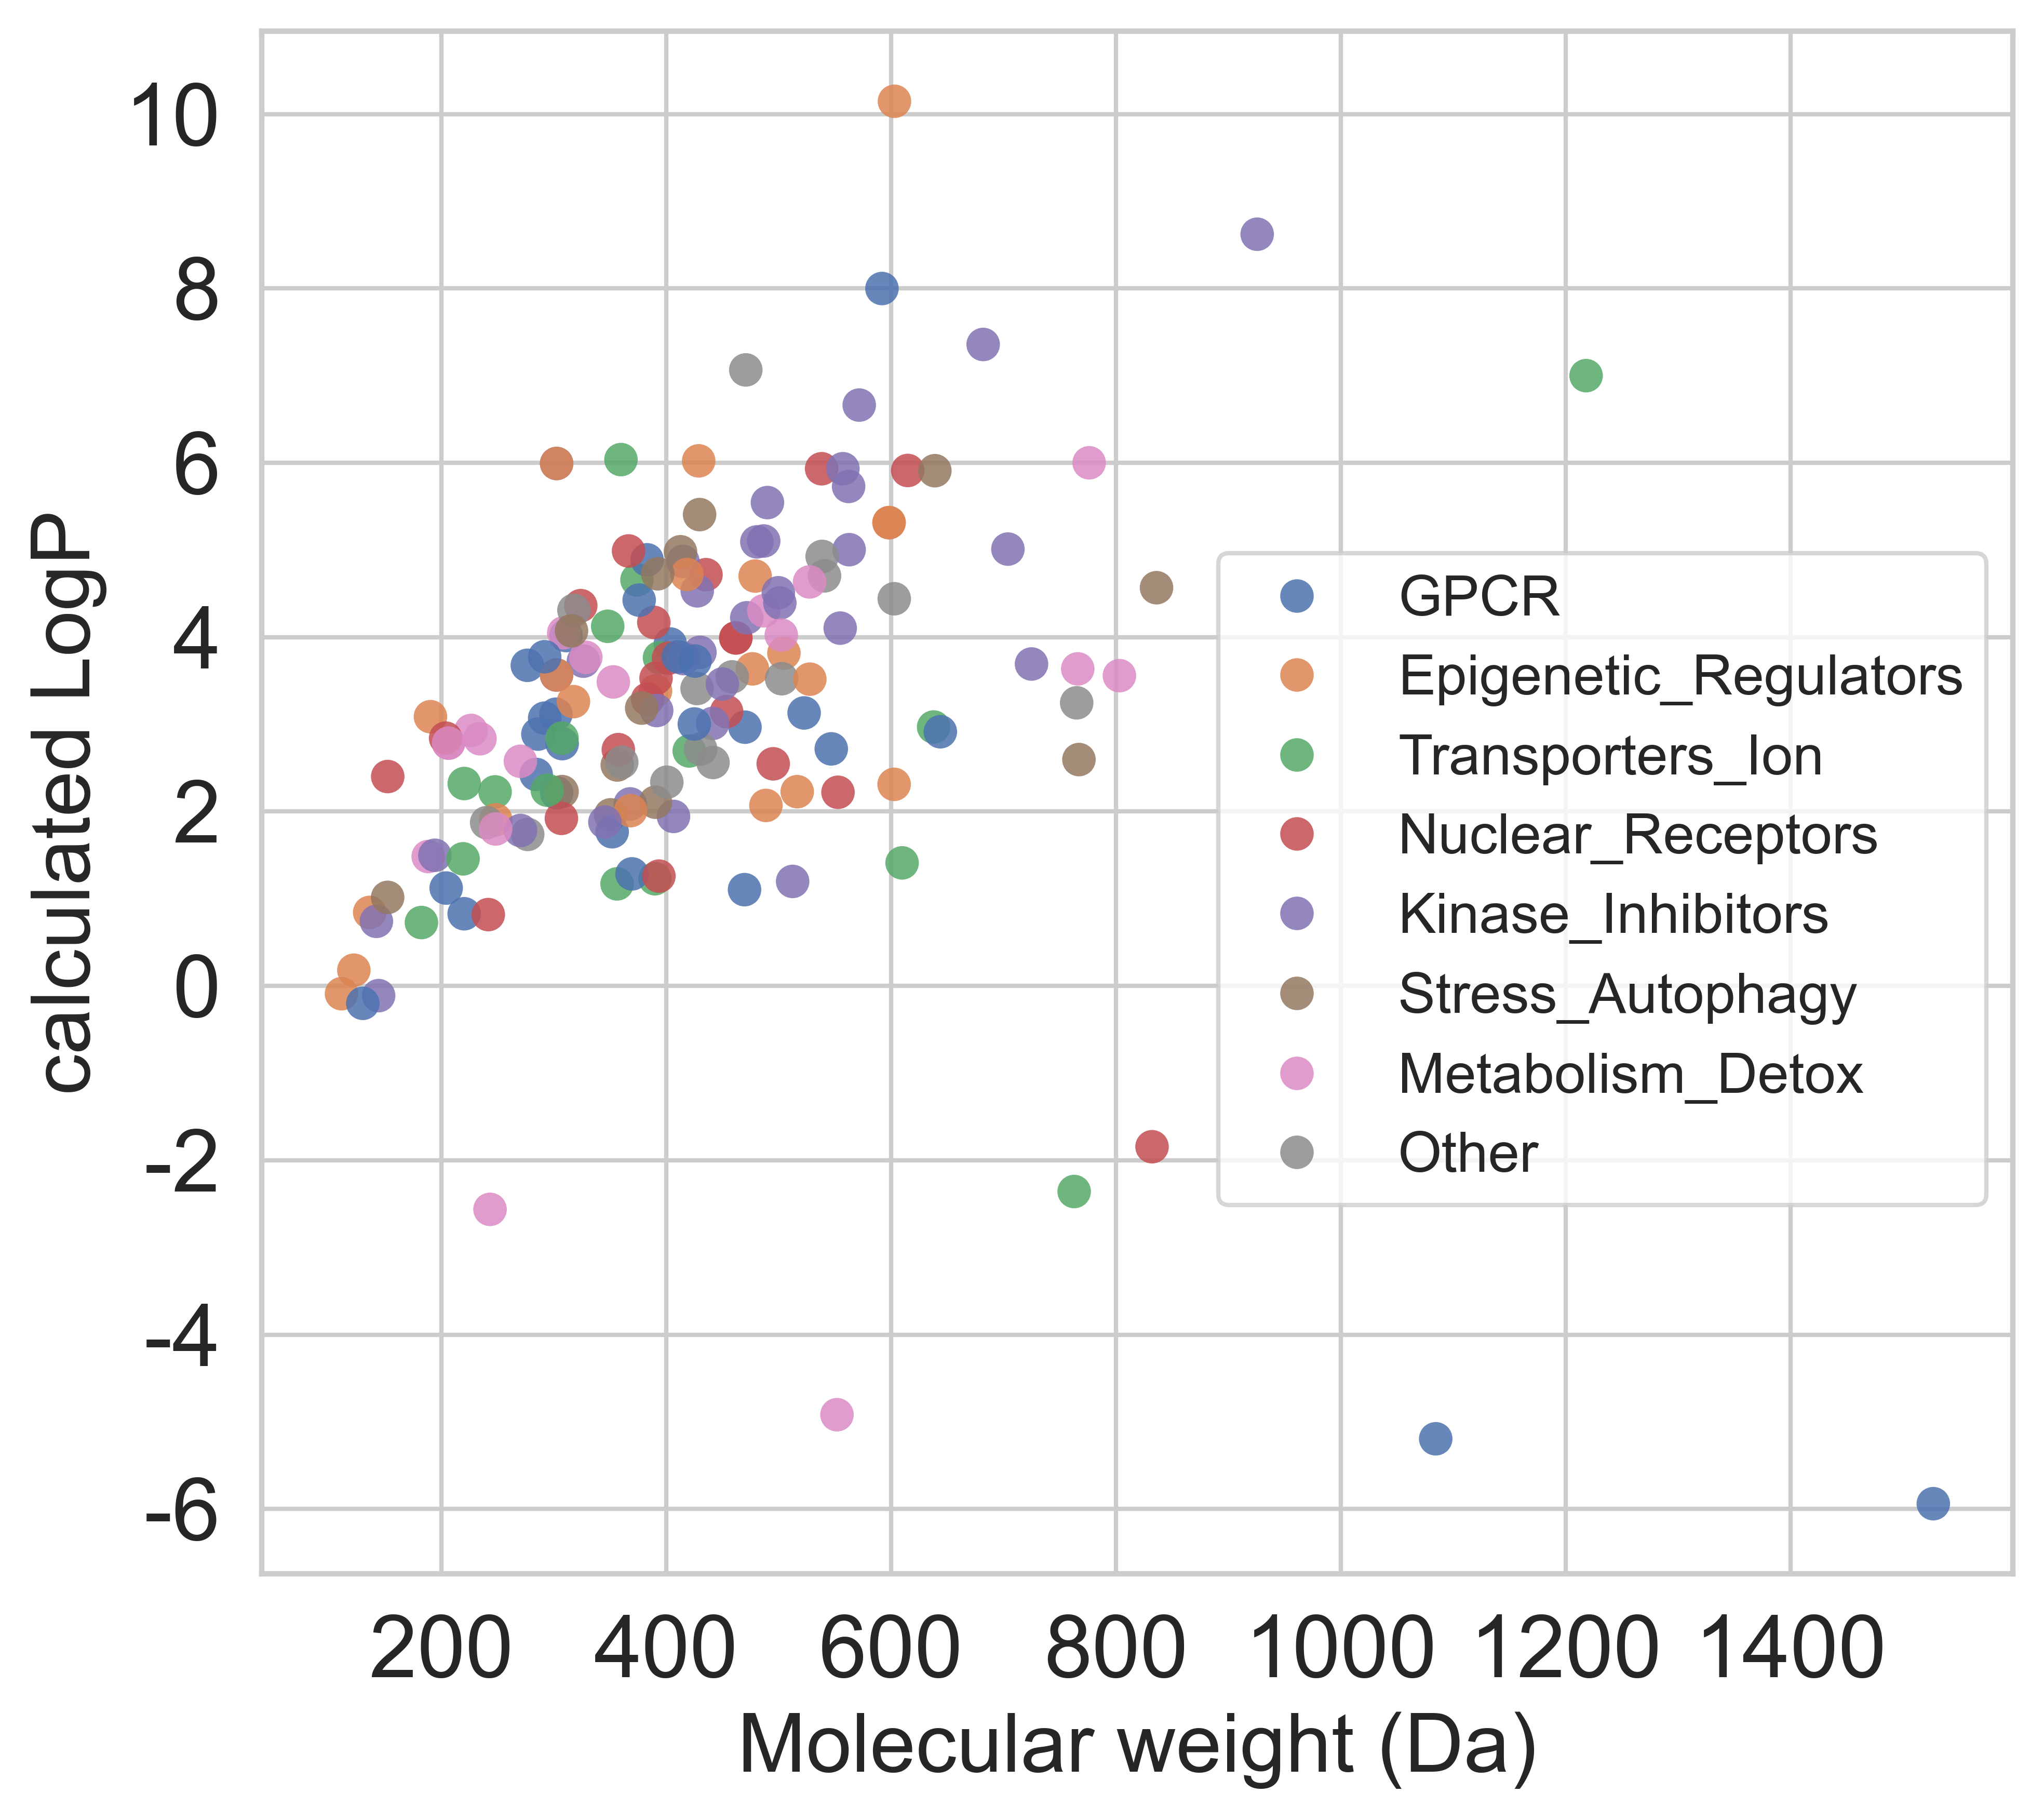

In [26]:

# ==========================
# 4. MW vs cLogP scatter plot
# ==========================
plt.figure(figsize=(6.8, 6))

sns.scatterplot(
    data=df_valid,
    x=mw_col,
    y="cLogP",
    hue=color_col,
    s=60,
    alpha=0.85,
    edgecolor="none"
)

plt.xlabel("Molecular weight (Da)", fontsize=19)
plt.ylabel("calculated LogP", fontsize=19)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
# plt.title("MW–cLogP Property Space of the Drug Library", fontsize=15)

plt.legend(bbox_to_anchor=(0.53, 0.68), loc="upper left", fontsize=13)
plt.tight_layout()

# Optional save
plt.savefig(f'{figure_path}\\scatter_MW_cLogP Property Space.svg', dpi=800)

plt.show()